IMPORTING LIBRARIES

In [17]:
import os
from PIL import Image
import pandas as pd
import numpy as np
import cv2
import random
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

THE PICTURE AS BEFORE

In [5]:
 # Display folder contents

def collect_image_info(base_folder):
    data = []
    for root, _, files in os.walk(base_folder):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                file_path = os.path.join(root, file)
                rel_folder = os.path.relpath(root, base_folder)
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        format = img.format
                except:
                    width = height = format = None        
                data.append({
                    "Folder": rel_folder,
                    "File Name": file,''
                    "Format": format,
                    "Size (W*h)": f"{width}x{height}",
                    })
    df = pd.DataFrame(data)
    return df

# Define a constant for dataset base folder
dataset_dir = "../train"
df_images = collect_image_info(dataset_dir)
print(df_images.head())
                
    

  Folder                                          File Name Format Size (W*h)
0      .  austin16-1-_png_jpg.rf.f9778fdd8affbeb90eb3ebf...   JPEG    512x512
1      .  austin16-10-_png_jpg.rf.bdf1f4e7a69ce9bac21199...   JPEG    512x512
2      .  austin16-100-_png_jpg.rf.4e070725caab66ba6d4e4...   JPEG    512x512
3      .  austin16-13-_png_jpg.rf.b391d71620978d8434a7ba...   JPEG    512x512
4      .  austin16-14-_png_jpg.rf.42618696cc2b00e32cd79e...   JPEG    512x512


DATA CLEANING 

In [6]:
# Function to check if an image file is valid
def is_valid_image(file_path):
    try:
        with Image.open(file_path) as img:
            img.verify()  # Verify that it's an image
        return True
    except (IOError, SyntaxError):
        return False

In [7]:
# Checking for corrupted images
dataset_directory = "../train"
corrupted_images = []

for root, dirs, files in os.walk(dataset_directory):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            if not is_valid_image(file_path):
                corrupted_images.append(file_path)

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
    print("No corrupted images found.")

No corrupted images found.


In [8]:
# Resizing and Normalizing the dataset

TARGET_SIZE = (224, 224)

def preprocess_image(file_path, save_dir):
    try:
        with Image.open(file_path) as img:
            img = img.convert('RGB')  # Ensure 3 color channels
            img = img.resize(TARGET_SIZE)  # Resize to target size

            # Normalize: convert to array and divide by 255 to scale to [0, 1]                  
            img_array = np.array(img) / 255.0  # Normalize to [0, 1]

            #Optional: Save the preprocessed image (remove this if just using in memory)
            save_path = os.path.join(save_dir, os.path.basename(file_path))
            img.save(save_path)  # Save the resized image

            return img_array  # Return array if needed for model input                                  
    except Exception as e:
        print(f"Failed to process {file_path}: {e}")
        return None

In [11]:
# Applying to all images 

input_directory = "../train"
output_directory = "../processed_train" 
os.makedirs(output_directory, exist_ok=True)    

for root, dirs, files in os.walk(input_directory):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
            file_path = os.path.join(root, file)
            preprocess_image(file_path, output_directory)

In [14]:
# Counting images per class
import os

dataset_path = '../train'

images = [f for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print("Total number of images:", len(images))


Total number of images: 6764


In [31]:
import os

folder_path = '../train'
 
files = os.listdir(folder_path)

for i, file in enumerate(files):
     if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
         new_name = f"img_{i+1:03d}.jpg"  # Change extension to .jpg
         old_path = os.path.join(folder_path, file)
         new_path = os.path.join(folder_path, new_name)
         os.rename(old_path, new_path)

         print("Renaming complete!")


Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming complete!
Renaming com

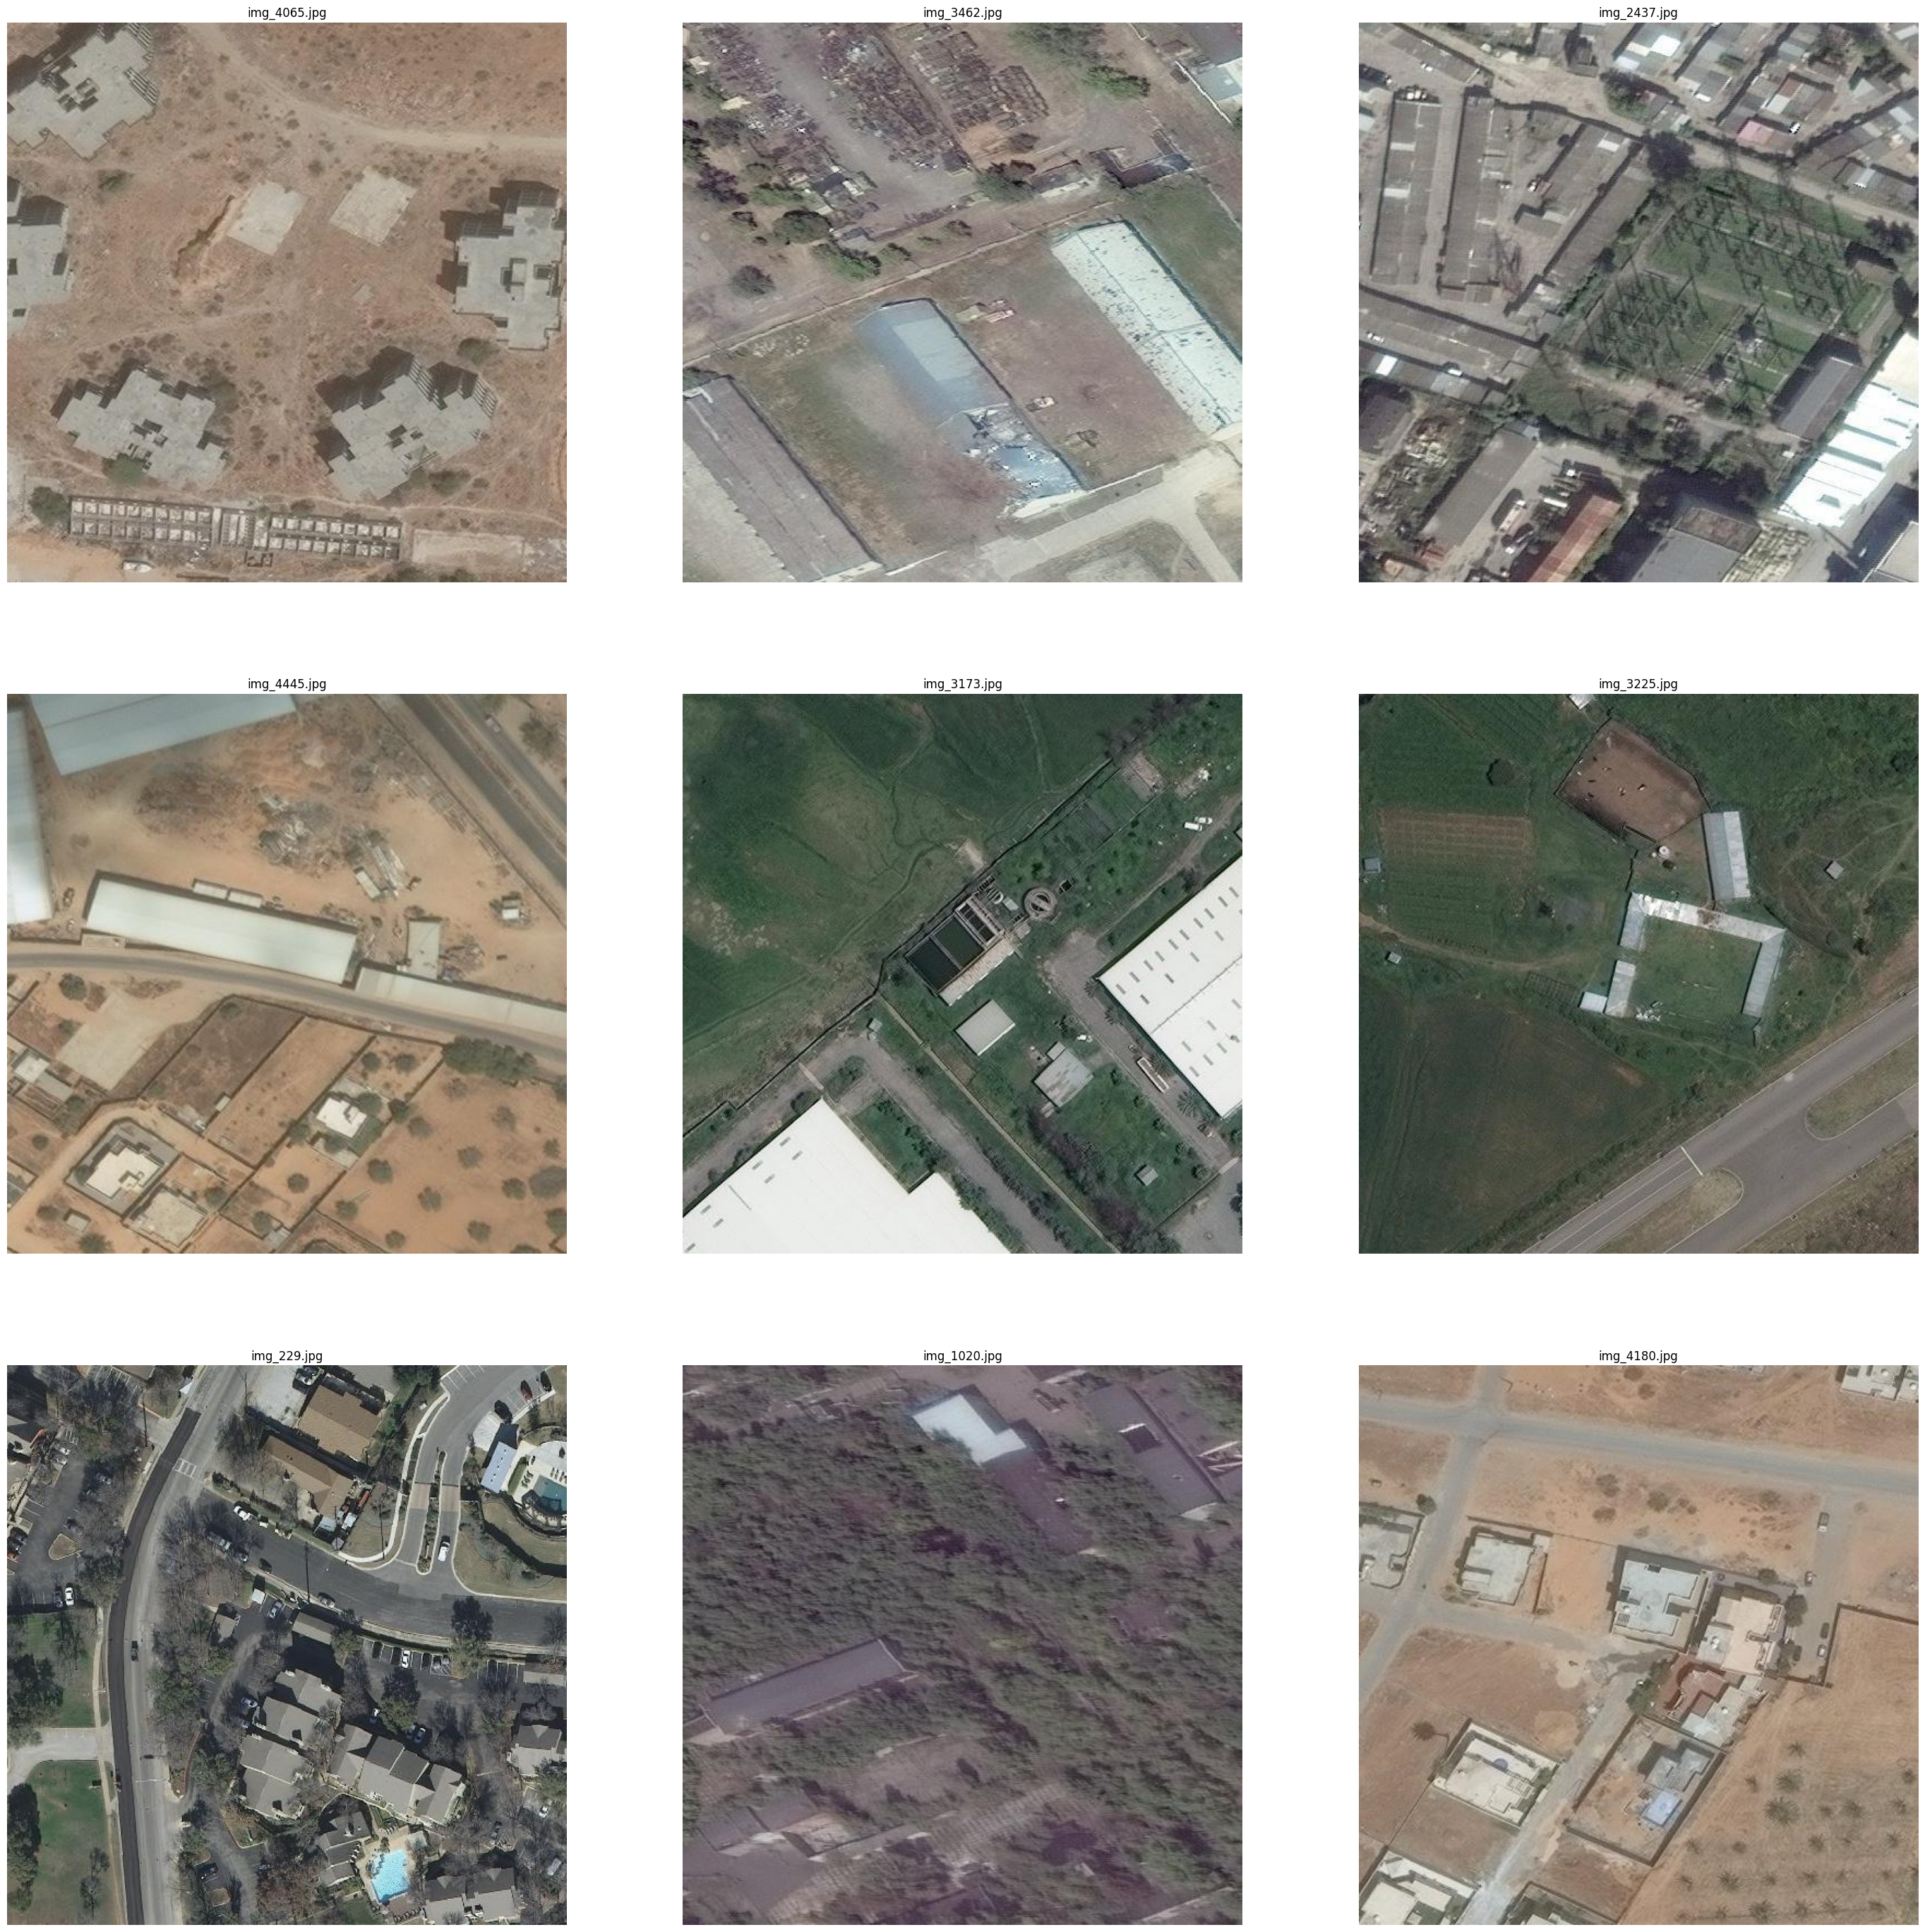

In [32]:
# Display random images from the dataset

dataset_path = '../train'

images = os.listdir(dataset_path)

# Select 9 random images

sample_images = random.sample(images, 9)

plt.figure(figsize=(35, 35))

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(dataset_path, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB for correct color display

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()

FEATURE EXTRACTION